In [1]:
import numpy as np
from pycbc.types import load_frequencyseries
from pycbc.psd import interpolate
import h5py

from matplotlib import pyplot as plt
plt.style.use('../paper.mplstyle')

import sys
import os

search_dir = os.path.abspath("../search")

if search_dir not in sys.path:
    sys.path.insert(0, search_dir)

import plotting_utils

/home/gareth.cabourndavies/environments/env_lisa_premerger_sangria/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


In [2]:
input_data = '../datasets/LDC2_sangria_hm_training.hdf' # The Sangria dataset

In [3]:
# days before merger to use as cutoffs
cutoff_days = [0.5, 1, 4, 7, 14]

time_before_colors = plotting_utils.get_colors(cutoff_days)
time_before_colors[0] = 'k'

In [4]:

hc_all = {}


signals = range(15)
with h5py.File('characteristic_strain/collected_characteristic_strain.hdf','r') as ccsf:
    freqs = ccsf['frequencies'][:]
    valid = freqs > 0
    freqs = freqs[valid]
    delta_f = ccsf.attrs['delta_f']

    for sig_num in signals:
        print(f'Signal {sig_num}')
        hc_all[sig_num] = {}
        grp = ccsf[str(sig_num)]
        for cutoff_day in cutoff_days + [0]:
            hc_all[sig_num][cutoff_day] = \
                np.sqrt(
                    grp[str(cutoff_day).replace('.','p') + '_A'][valid] ** 2 +
                    grp[str(cutoff_day).replace('.','p') + '_E'][valid] ** 2
                )


Signal 0
Signal 1
Signal 2
Signal 3
Signal 4
Signal 5
Signal 6
Signal 7
Signal 8
Signal 9
Signal 10
Signal 11
Signal 12
Signal 13
Signal 14


Lets compute the expected SNR from characteristic strain for each signal and each time before merger

In [5]:
# Typical PSD
psd = load_frequencyseries('model_AE_SMOOTHED_PSD.txt')

# interpolate the PSD so that it matches the signal PSD
psd = interpolate(psd, delta_f)
psd[0] = 0
psd.resize(len(freqs))


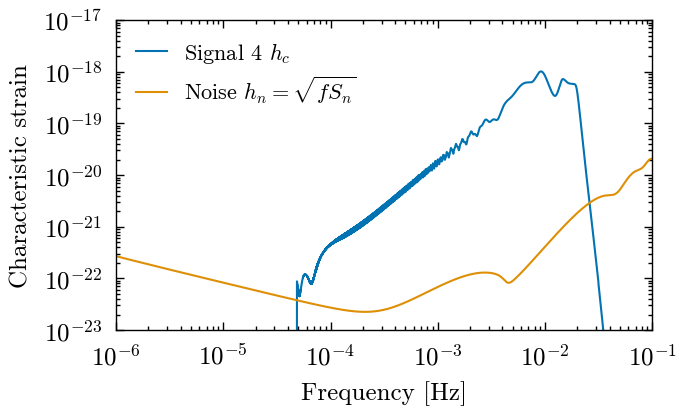

In [6]:

example_signal = 4
# Plot an example
hn = np.sqrt(freqs * psd)  # characteristic noise curve

fig, ax  = plt.subplots(1)
print
ax.loglog(freqs, hc_all[example_signal][0], label=f'Signal {example_signal} $h_c$')
ax.loglog(freqs, hn, label='Noise $h_n = \sqrt{f S_n}$')
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Characteristic strain')
ax.set_ylim(1e-23, 1e-17)
ax.set_xlim(1e-6, 0.1)
ax.legend(loc='upper left')

In [7]:
# Get the truth times
import ldc.io.hdf5 as hdfio

input_data = '../datasets/LDC2_sangria_hm_training.hdf'
mbhb_sky = hdfio.load_array(input_data, name="sky/mbhb/cat")

truth_times_days = mbhb_sky[0]['CoalescenceTime'] / 86400

table_str = """\\begin{tabular}{|cc|c|ccccc|}
\\hline
\\multicolumn{2}{|c|}{Signal}& \multicolumn{6}{c|}{Expected SNR} \\\\
\\hline
Number & Time  & Full Signal & 0.5 & 1 & 4 & 7 & 14 \\\\
\\hline
"""
for sig_num, days in zip(signals, truth_times_days):
    table_row = f"{sig_num} & {days:.2f}"
    for cutoff_day in [0] + cutoff_days:
        h_c_tbefore  = hc_all[sig_num][cutoff_day]
        valid = hn > 0
        snr2 = np.trapezoid((h_c_tbefore[valid] / hn[valid])**2, np.log(freqs[valid]))
        snr = np.sqrt(snr2)
        table_row += f" & {snr:.2f}"
    table_row += " \\\\\n"
    table_str += table_row
table_str += """\\hline
\\end{tabular}"""

with open("../paper/characteristic_strain_table.tex", 'w') as table_file:
    table_file.write(table_str)
    print(table_str)

    

\begin{tabular}{|cc|c|ccccc|}
\hline
\multicolumn{2}{|c|}{Signal}& \multicolumn{6}{c|}{Expected SNR} \\
\hline
Number & Time  & Full Signal & 0.5 & 1 & 4 & 7 & 14 \\
\hline
0 & 55.56 & 2699.04 & 70.99 & 52.74 & 24.33 & 16.43 & 9.51 \\
1 & 101.23 & 105.72 & 3.99 & 2.49 & 0.79 & 0.47 & 0.28 \\
2 & 129.26 & 400.25 & 10.76 & 7.51 & 2.91 & 1.84 & 1.07 \\
3 & 130.31 & 1992.38 & 71.92 & 54.76 & 27.52 & 19.88 & 13.22 \\
4 & 133.41 & 3475.28 & 115.99 & 88.26 & 44.02 & 31.65 & 20.46 \\
5 & 138.55 & 427.13 & 16.40 & 10.79 & 3.85 & 2.37 & 1.22 \\
6 & 157.61 & 673.48 & 24.99 & 16.19 & 5.48 & 3.25 & 1.55 \\
7 & 191.34 & 579.12 & 15.72 & 10.70 & 4.02 & 2.56 & 1.49 \\
8 & 199.60 & 365.18 & 16.21 & 10.68 & 3.77 & 2.28 & 1.11 \\
9 & 215.34 & 392.96 & 18.69 & 12.41 & 4.75 & 3.12 & 1.82 \\
10 & 236.41 & 2187.78 & 45.09 & 31.90 & 12.71 & 8.13 & 4.37 \\
11 & 257.27 & 1200.55 & 45.32 & 33.31 & 13.99 & 8.92 & 4.71 \\
12 & 271.29 & 359.02 & 21.27 & 14.71 & 6.10 & 4.17 & 2.57 \\
13 & 282.51 & 823.00 & 24.75 & 1